# Census Income Prediction — ML Model

Goal: predict whether a person's annual income is **>50K** or **<=50K** using the Census Income (Adult) dataset.

This notebook covers the ML part first. After this works, we will connect the saved model to a FastAPI backend and then to a React dashboard.

In [ ]:
!pip -q install scikit-learn pandas numpy matplotlib seaborn joblib


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 1. Load the dataset

In [4]:
adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame.copy()

print('Shape:', df.shape)
display(df.head())


Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
print('Columns:')
print(df.columns.tolist())
print('\nMissing values:')
print(df.isna().sum().sort_values(ascending=False).head(10))

print('\nTarget distribution:')
print(df['class'].value_counts())


Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']

Missing values:
occupation        2809
workclass         2799
native-country     857
fnlwgt               0
education            0
education-num        0
age                  0
marital-status       0
relationship         0
sex                  0
dtype: int64

Target distribution:
class
<=50K    37155
>50K     11687
Name: count, dtype: int64


## 2. Basic data exploration

We check the target distribution before training.

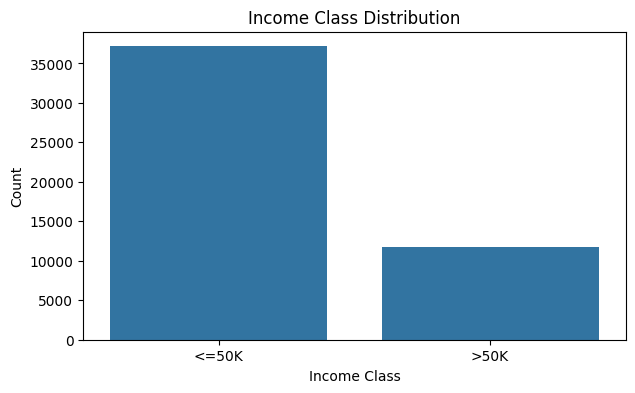

In [6]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='class')
plt.title('Income Class Distribution')
plt.xlabel('Income Class')
plt.ylabel('Count')
plt.show()


## 3. Prepare X and y

The target is `class`. We convert it to two clean labels: `<=50K` and `>50K`.

In [7]:
X = df.drop(columns=['class'])
y = df['class'].astype(str).str.replace('.', '', regex=False)

print('Target values:', y.unique())
print('X shape:', X.shape)


Target values: ['<=50K' '>50K']
X shape: (48842, 14)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))


Training samples: 39073
Testing samples: 9769


## 4. Preprocessing

Categorical columns are one-hot encoded. Numerical columns are imputed and scaled. The preprocessing is kept inside the pipeline so the exact same steps can later be used by the website/API.

In [9]:
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


## 5. Train Logistic Regression

In [12]:
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)
logistic_pred = logistic_pipeline.predict(X_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, logistic_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, logistic_pred))


Logistic Regression Accuracy: 0.8523902139420616

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7431
        >50K       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769



## 6. Train Random Forest

In [13]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.8576108097041663

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.74      0.63      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.86      0.85      9769



## 7. Compare model metrics

In [14]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, logistic_pred), accuracy_score(y_test, rf_pred)]
})
display(results.sort_values('Accuracy', ascending=False))


,Model,Accuracy
1,Random Forest,0.857611
0,Logistic Regression,0.852390


## 8. Confusion Matrix

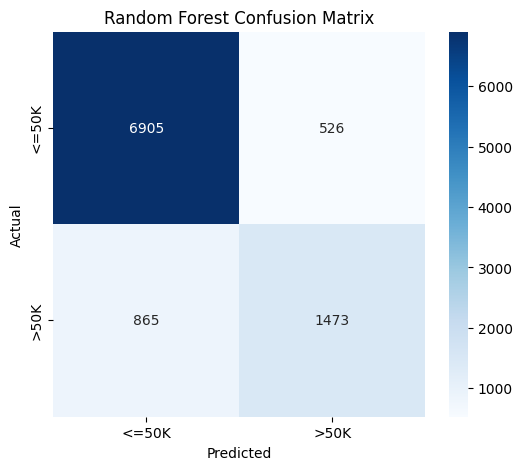

In [15]:
cm = confusion_matrix(y_test, rf_pred, labels=['<=50K', '>50K'])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()


## 9. Save the trained pipeline

We save the entire preprocessing + model pipeline. This is important because the React dashboard will later send raw user inputs to the API.

In [16]:
joblib.dump(rf_pipeline, 'census_income_model.pkl')
print('Saved: census_income_model.pkl')


Saved: census_income_model.pkl


## 10. Test one sample prediction

This is a simple test before connecting the model to the backend.

In [17]:
sample = X_test.iloc[[0]]
sample_prediction = rf_pipeline.predict(sample)[0]

print('Sample input:')
display(sample)
print('Predicted income class:', sample_prediction)


Sample input:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
40342,54,Private,115602,HS-grad,9,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,40,United-States


Predicted income class: <=50K


In [18]:
# KNN Classifier

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

# Train KNN model
knn_pipeline.fit(X_train, y_train)

# Predictions
knn_pred = knn_pipeline.predict(X_test)

# Evaluation
print("KNN Results")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, knn_pred))

KNN Results
Accuracy: 0.8336574879721568

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.89      7431
        >50K       0.67      0.61      0.64      2338

    accuracy                           0.83      9769
   macro avg       0.77      0.76      0.76      9769
weighted avg       0.83      0.83      0.83      9769



In [20]:
# Naive Bayes Classifier

from sklearn.base import clone

# Create a separate preprocessor for Naive Bayes
nb_preprocessor = clone(preprocessor)

# Make OneHotEncoder produce dense output
nb_preprocessor.set_params(
    cat__onehot__sparse_output=False
)

# Create Naive Bayes pipeline
nb_pipeline = Pipeline([
    ('preprocessor', nb_preprocessor),
    ('model', GaussianNB())
])

# Train Naive Bayes model
nb_pipeline.fit(X_train, y_train)

# Predictions
nb_pred = nb_pipeline.predict(X_test)

# Evaluation
print("Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Results
Accuracy: 0.6204319787081585

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.96      0.53      0.68      7431
        >50K       0.38      0.92      0.54      2338

    accuracy                           0.62      9769
   macro avg       0.67      0.72      0.61      9769
weighted avg       0.82      0.62      0.64      9769



In [21]:
# Decision Tree Classifier

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Train Decision Tree model
dt_pipeline.fit(X_train, y_train)

# Predictions
dt_pred = dt_pipeline.predict(X_test)

# Evaluation
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

Decision Tree Results
Accuracy: 0.8141058450199611

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88      7431
        >50K       0.61      0.62      0.61      2338

    accuracy                           0.81      9769
   macro avg       0.74      0.75      0.75      9769
weighted avg       0.82      0.81      0.81      9769



In [22]:
# Support Vector Machine (SVM)

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', random_state=42))
])

# Train SVM model
svm_pipeline.fit(X_train, y_train)

# Predictions
svm_pred = svm_pipeline.predict(X_test)

# Evaluation
print("SVM Results")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

SVM Results
Accuracy: 0.8595557375371071

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7431
        >50K       0.77      0.59      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769



In [23]:
# AdaBoost Classifier

adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', AdaBoostClassifier(random_state=42))
])

# Train AdaBoost model
adaboost_pipeline.fit(X_train, y_train)

# Predictions
adaboost_pred = adaboost_pipeline.predict(X_test)

# Evaluation
print("AdaBoost Results")
print("Accuracy:", accuracy_score(y_test, adaboost_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, adaboost_pred))


AdaBoost Results
Accuracy: 0.8563824342307299

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7431
        >50K       0.76      0.58      0.66      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.76      0.78      9769
weighted avg       0.85      0.86      0.85      9769



In [24]:
!pip -q install xgboost

In [25]:
from xgboost import XGBClassifier

In [27]:
# Convert target labels into 0 and 1 for XGBoost
y_train_xgb = y_train.map({
    '<=50K': 0,
    '>50K': 1
})

y_test_xgb = y_test.map({
    '<=50K': 0,
    '>50K': 1
})

# Convert target labels into 0 and 1 for XGBoost
y_train_xgb = y_train.map({
    '<=50K': 0,
    '>50K': 1
})

y_test_xgb = y_test.map({
    '<=50K': 0,
    '>50K': 1
})

# XGBoost model
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    ))
])

# Train
xgb_pipeline.fit(X_train, y_train_xgb)

# Prediction
xgb_pred = xgb_pipeline.predict(X_test)

# Evaluation
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test_xgb, xgb_pred))
print("\nClassification Report:\n")
print(classification_report(
    y_test_xgb,
    xgb_pred,
    target_names=['<=50K', '>50K']
))

XGBoost Results
Accuracy: 0.8759340771829256

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      7431
        >50K       0.80      0.65      0.71      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": logistic_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred,
    "Naive Bayes": nb_pred,
    "Decision Tree": dt_pred,
    "SVM": svm_pred,
    "AdaBoost": adaboost_pred,
    "XGBoost": xgb_pred
}

results = []

for name, pred in models.items():

    # XGBoost uses 0/1 labels
    if name == "XGBoost":
        actual_y = y_test_xgb
    else:
        actual_y = y_test

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(actual_y, pred),
        "Precision": precision_score(actual_y, pred, pos_label=1 if name == "XGBoost" else ">50K"),
        "Recall": recall_score(actual_y, pred, pos_label=1 if name == "XGBoost" else ">50K"),
        "F1-Score": f1_score(actual_y, pred, pos_label=1 if name == "XGBoost" else ">50K")
    })

results_df = pd.DataFrame(results)

results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.852390,0.741379,0.588537,0.656175
1,Random Forest,0.857611,0.736868,0.630026,0.679271
2,KNN,0.833657,0.668081,0.606074,0.635569
3,Naive Bayes,0.620432,0.379359,0.921300,0.537425
4,Decision Tree,0.814106,0.609848,0.619760,0.614765
5,SVM,0.859556,0.768931,0.590676,0.668118
6,AdaBoost,0.856382,0.764873,0.577417,0.658055
7,XGBoost,0.875934,0.797569,0.645423,0.713475


In [33]:
from sklearn.model_selection import GridSearchCV

# Simple Random Forest hyperparameter optimization
rf_param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 20]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(rf_grid.best_score_)

Best Parameters:
{'model__max_depth': 20, 'model__n_estimators': 100}

Best Cross-Validation Accuracy:
0.8617203072483438


In [34]:
!pip -q install imbalanced-learn

In [35]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SMOTE + Random Forest
smote_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train
smote_pipeline.fit(X_train, y_train)

# Prediction
smote_pred = smote_pipeline.predict(X_test)

print("SMOTE + Random Forest Results")
print("Accuracy:", accuracy_score(y_test, smote_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, smote_pred))

SMOTE + Random Forest Results
Accuracy: 0.8454294195925888

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.90      0.89      0.90      7431
        >50K       0.67      0.70      0.68      2338

    accuracy                           0.85      9769
   macro avg       0.79      0.79      0.79      9769
weighted avg       0.85      0.85      0.85      9769



In [36]:
# Bias-Variance: Training vs Testing Accuracy

train_accuracy = rf_pipeline.score(X_train, y_train)
test_accuracy = rf_pipeline.score(X_test, y_test)

print("Bias-Variance Analysis")
print("----------------------")
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)
print("Difference        :", train_accuracy - test_accuracy)

Bias-Variance Analysis
----------------------
Training Accuracy: 0.9994113582269086
Testing Accuracy : 0.8576108097041663
Difference        : 0.14180054852274238


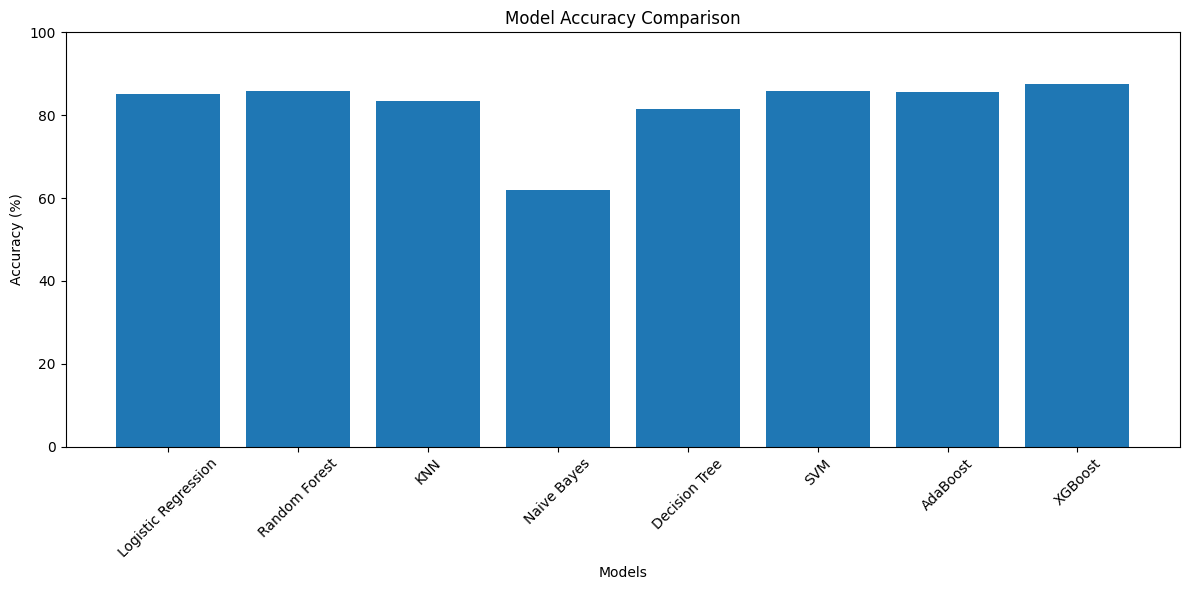

In [37]:
import matplotlib.pyplot as plt

# Accuracy comparison
plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"] * 100
)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

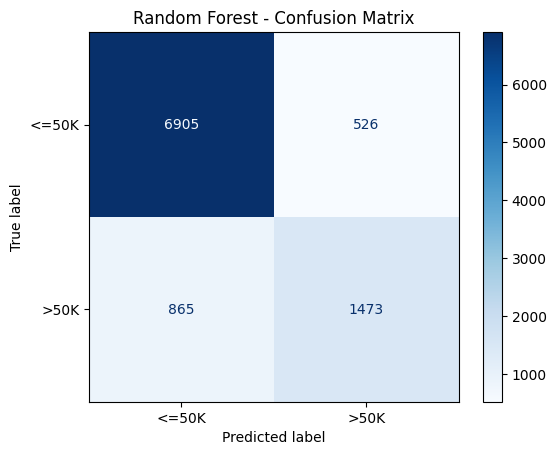

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix for Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

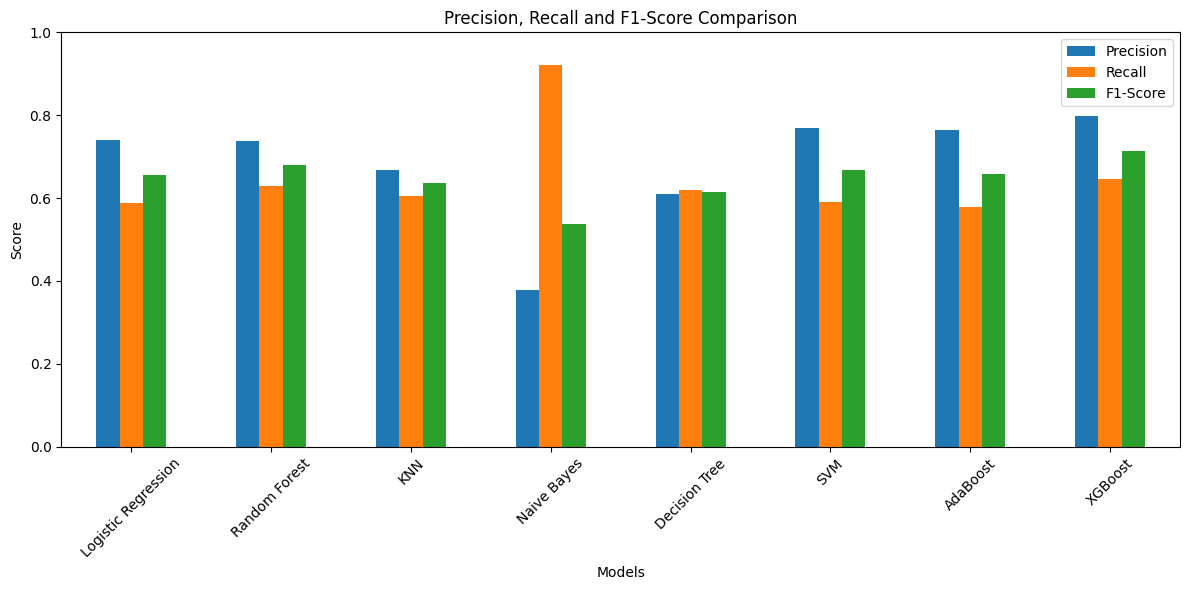

In [39]:
# Precision, Recall and F1-Score comparison

metrics_df = results_df.set_index("Model")[
    ["Precision", "Recall", "F1-Score"]
]

metrics_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Precision, Recall and F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Random Forest AUC: 0.9010783726969038


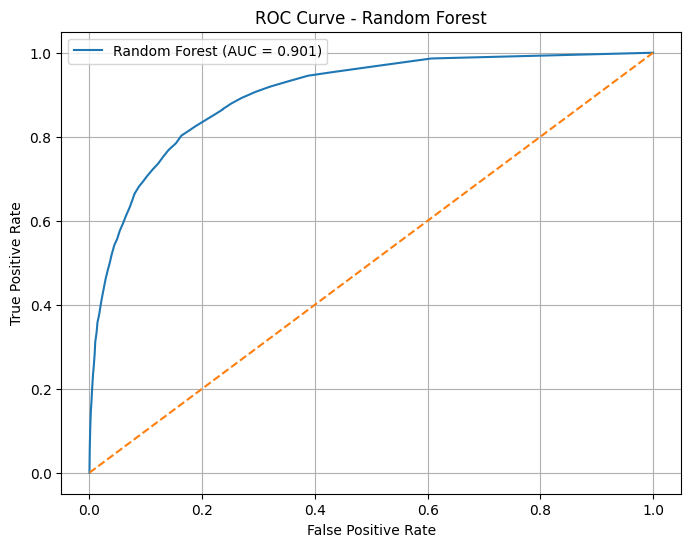

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# Convert target to 0 and 1
y_test_binary = y_test.map({
    '<=50K': 0,
    '>50K': 1
})

# ROC values
fpr, tpr, thresholds = roc_curve(y_test_binary, rf_prob)

# AUC
auc_score = roc_auc_score(y_test_binary, rf_prob)

print("Random Forest AUC:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

In [41]:
import joblib

# Save the Random Forest model
joblib.dump(rf_pipeline, 'census_income_model.pkl')

print("Final model saved successfully!")
print("File: census_income_model.pkl")

Final model saved successfully!
File: census_income_model.pkl


In [44]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("CV Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.8498311  0.85034292 0.85391073 0.85380835 0.85851761]
Mean CV Accuracy: 0.8532821422190857
CV Standard Deviation: 0.003118680790851326


In [45]:
# ==========================================
# FINAL PROJECT CONCLUSION
# ==========================================

# Find model with highest accuracy
best_accuracy_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

# Find model with highest F1-score
best_f1_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]

# Accuracy percentage
accuracy_percent = best_accuracy_model["Accuracy"] * 100
f1_percent = best_f1_model["F1-Score"] * 100

print("=" * 60)
print("              FINAL PROJECT CONCLUSION")
print("=" * 60)

print("\n1. PROJECT OBJECTIVE")
print("The project successfully predicts whether a person's annual income")
print("is <=50K or >50K using Census Income data and Machine Learning.")

print("\n2. MODELS IMPLEMENTED")
print("Multiple classification models were implemented and evaluated,")
print("including Logistic Regression, Random Forest, KNN, Naive Bayes,")
print("Decision Tree, SVM, AdaBoost and XGBoost.")

print("\n3. MODEL EVALUATION")
print(f"The highest Accuracy among the tested models was achieved by:")
print(f"{best_accuracy_model['Model']} with {accuracy_percent:.2f}% accuracy.")

print(f"\nThe highest F1-Score was obtained by:")
print(f"{best_f1_model['Model']} with {f1_percent:.2f}% F1-Score.")

print("\n4. PERFORMANCE METRICS")
print("Accuracy, Precision, Recall and F1-Score were used to evaluate")
print("the classification performance of the models.")

print("\n5. MODEL EVALUATION TECHNIQUES")
print("Cross Validation, Hyperparameter Optimization, SMOTE and")
print("Bias-Variance analysis were also performed.")

print("\n6. FINAL CONCLUSION")
print("The results demonstrate that Machine Learning can be effectively")
print("used for Census Income Classification. Different algorithms")
print("produced different performance levels, showing the importance")
print("of model selection and evaluation using multiple performance metrics.")

print("\n7. DEPLOYMENT")
print("The trained Random Forest pipeline was saved as")
print("'census_income_model.pkl' for integration with the prediction website.")

print("\n" + "=" * 60)
print("                 PROJECT COMPLETED")
print("=" * 60)

              FINAL PROJECT CONCLUSION

1. PROJECT OBJECTIVE
The project successfully predicts whether a person's annual income
is <=50K or >50K using Census Income data and Machine Learning.

2. MODELS IMPLEMENTED
Multiple classification models were implemented and evaluated,
including Logistic Regression, Random Forest, KNN, Naive Bayes,
Decision Tree, SVM, AdaBoost and XGBoost.

3. MODEL EVALUATION
The highest Accuracy among the tested models was achieved by:
XGBoost with 87.59% accuracy.

The highest F1-Score was obtained by:
XGBoost with 71.35% F1-Score.

4. PERFORMANCE METRICS
Accuracy, Precision, Recall and F1-Score were used to evaluate
the classification performance of the models.

5. MODEL EVALUATION TECHNIQUES
Cross Validation, Hyperparameter Optimization, SMOTE and
Bias-Variance analysis were also performed.

6. FINAL CONCLUSION
The results demonstrate that Machine Learning can be effectively
used for Census Income Classification. Different algorithms
produced different per

In [46]:
from google.colab import files

files.download('census_income_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>